In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

import omegaconf
import dataclasses

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:

import matplotlib.patches as patches


def add_largest_maze_walls(ax):    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.025 * 80

    height, width = 7, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size + 18
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size + 12
        h, w = h * block_size * 2, w * block_size * 2
        w = w * 1.
        y = y * 1.
        rect = patches.Rectangle((x, y), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)
        
  

from matplotlib.patches import Polygon
class VectorizedPlusWorld:
    def __init__(self, delta=0.1, batch_size=1024):
        self.delta = delta
        self.bounds = (-1.0, 1.0)
        self.batch_size = batch_size

    def reset(self, position=None):
        if position is None:
            states = self.sample_valid_states(self.batch_size)
        else:
            states = np.array(position).reshape(1, 2).repeat(self.batch_size, 1)
        return states
    
    def step(self, states, actions, step_size=0.05):
        """
        states: (N, 2) array
        actions: (N, 2) array
        Returns: next_states (N, 2)
        """
        # 1. Proposed movement
        next_states = states + actions * step_size
        
        # 2. Global boundary clipping (The outer square)
        next_states = np.clip(next_states, self.bounds[0], self.bounds[1])
        
        # 3. Identify which proposed states are invalid (in the corners)
        # A state is valid if |x| <= delta OR |y| <= delta
        is_valid = (np.abs(next_states[:, 0]) <= self.delta) | (np.abs(next_states[:, 1]) <= self.delta)
        invalid_mask = ~is_valid
        
        # 4. Sliding Logic for invalid states
        # We need to know where they were BEFORE the invalid move
        in_horizontal = np.abs(states[:, 1]) <= self.delta
        in_vertical = np.abs(states[:, 0]) <= self.delta
        
        # For those that moved from horizontal into a corner: clip their Y
        # For those that moved from vertical into a corner: clip their X
        
        # Apply Y-clipping for those in the horizontal corridor hitting a wall
        next_states[invalid_mask & in_horizontal, 1] = np.clip(
            next_states[invalid_mask & in_horizontal, 1], -self.delta, self.delta
        )
        
        # Apply X-clipping for those in the vertical corridor hitting a wall
        next_states[invalid_mask & in_vertical, 0] = np.clip(
            next_states[invalid_mask & in_vertical, 0], -self.delta, self.delta
        )
        
        return next_states

    def sample_valid_states(self, n):
        """Uniformly samples n states from the plus-shaped manifold."""
        states = np.zeros((n, 2))
        
        # Randomly decide which corridor each agent starts in
        # 0 = Horizontal corridor, 1 = Vertical corridor
        choices = np.random.randint(0, 2, size=n)
        
        # Horizontal: x in [-1, 1], y in [-delta, delta]
        h_mask = (choices == 0)
        states[h_mask, 0] = np.random.uniform(-1, 1, size=np.sum(h_mask))
        states[h_mask, 1] = np.random.uniform(-self.delta, self.delta, size=np.sum(h_mask))
        
        # Vertical: x in [-delta, delta], y in [-1, 1]
        v_mask = (choices == 1)
        states[v_mask, 0] = np.random.uniform(-self.delta, self.delta, size=np.sum(v_mask))
        states[v_mask, 1] = np.random.uniform(-1, 1, size=np.sum(v_mask))
        
        return states

    def sample_random_walk(self, steps=1000, max_repeat=20):
        """
        Generates a batch of trajectories where actions are held for multiple steps.
        max_repeat: The maximum number of steps an action can be held.
        """
        # 1. Initialize states at the center
        states = self.sample_valid_states(self.batch_size)
        state_history = []
        action_history = []
        
        # 2. Buffers to track action persistence
        active_actions = np.zeros((self.batch_size, 2))
        steps_left = np.zeros(self.batch_size, dtype=int)

        for _ in range(steps):
            # 3. Identify agents that need a new action (counter reached 0)
            needs_new_action = steps_left <= 0
            num_new = np.sum(needs_new_action)

            if num_new > 0:
                # Sample new directions
                new_actions = np.random.uniform(-1, 1, size=(num_new, 2))
                # Normalize to unit length for consistent speed
                # new_actions /= (np.linalg.norm(new_actions, axis=1, keepdims=True) + 1e-8)
                
                active_actions[needs_new_action] = new_actions
                
                # Sample new durations (e.g., between 1 and max_repeat)
                steps_left[needs_new_action] = np.random.randint(1, max_repeat + 1, size=num_new)


            state_history.append(states.copy())

            # 4. Execute the step for the entire batch
            states = self.step(states, active_actions)
            action_history.append(active_actions.copy())

            # 5. Decrement the counters
            steps_left -= 1
            
        return np.array(state_history), np.array(action_history)
    
    
    
    def plot_plus_world_boundaries(self, ax):
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 6))

        delta = self.delta
        # 1. Define the 12 vertices of the "Plus" shape
        # Starting from top-left of the vertical corridor and going clockwise
        vertices = [
            (-delta, 1.0),  (delta, 1.0),   # Top
            (delta, delta), (1.0, delta),   # Top-Right corner turn
            (1.0, -delta),  (delta, -delta),# Bottom-Right corner turn
            (delta, -1.0),  (-delta, -1.0), # Bottom
            (-delta, -delta), (-1.0, -delta),# Bottom-Left corner turn
            (-1.0, delta),  (-delta, delta) # Top-Left corner turn
        ]
        
        # 2. Draw the valid corridor outline
        plus_shape = Polygon(vertices, closed=True, facecolor='none', edgecolor='black', linewidth=3, label='Environment Walls')
        ax.add_patch(plus_shape)

        # 3. Shade the "Invalid" Ghost Zones (The four corners)
        # Top-Right, Top-Left, Bottom-Right, Bottom-Left
        corners = [
            [(delta, delta), (1.0, delta), (1.0, 1.0), (delta, 1.0)],
            [(-delta, delta), (-1.0, delta), (-1.0, 1.0), (-delta, 1.0)],
            [(delta, -delta), (1.0, -delta), (1.0, -1.0), (delta, -1.0)],
            [(-delta, -delta), (-1.0, -delta), (-1.0, -1.0), (-delta, -1.0)]
        ]
        
        for i, corner_coords in enumerate(corners):
            label = "Unreachable Space" if i == 0 else None
            corner_poly = Polygon(corner_coords, closed=True, alpha=0.0, label=label, hatch='/',)
            ax.add_patch(corner_poly)

        # 4. Formatting
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)
        ax.set_aspect('equal')
        # ax.set_xlabel('$x$-coordinate', fontsize=12)
        # ax.set_ylabel('$y$-coordinate', fontsize=12)
        # ax.set_title(f'Plus-World Manifold ($\delta={delta}$)', fontsize=14, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right', fontsize=10)

        return ax
 
 
 
env = VectorizedPlusWorld(batch_size=1)

In [3]:
ENV_NAME = 'quadruped' # cheetah | walker | antmaze | plusmaze | quadruped

In [4]:
NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

In [5]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
from dm_control import suite

if ENV_NAME == 'cheetah':
    STATE_DIM = 17
    ACTION_DIM = 6
    # AUX_DIM = 1
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')
    angmomentum_aux = np.load('datasets/angmomentum_aux_cheetah.npy')
    aux = np.concatenate((
        aux.reshape(10000, 1000, 1),
        angmomentum_aux.reshape(10000, 1000, 1)
    ), axis=-1)
    # dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 1)), axis=-1)
    
elif ENV_NAME == 'walker':
    STATE_DIM = 24
    ACTION_DIM = 6
    # AUX_DIM = 3
    env = suite.load(
        domain_name='walker',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')
    angmomentum_aux = np.load('datasets/angmomentum_aux_walker.npy')
    aux = np.concatenate((
        aux.reshape(10000, 1000, 3),
        angmomentum_aux.reshape(10000, 1000, 1)
    ), axis=-1)
    # dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)
    
elif ENV_NAME == 'quadruped':
    STATE_DIM = 78
    ACTION_DIM = 12
    AUX_DIM = 5
    NUM_TRAJECTORIES = 10000
    TRAJECTORY_LEN = 1001
    env = suite.load(
        domain_name='quadruped',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    # dataset = np.load('datasets/quadruped_rnd.npy')
    dataset = np.load('datasets/quadruped_rnd_without_physics.npy', allow_pickle=True).item()
    # dataset['observations'] 'actions' 'physics'
    aux = np.load('datasets/aux_quadruped.npy', allow_pickle=True)
    
    # dataset['terminals'] = np.full((NUM_TRAJECTORIES, TRAJECTORY_LEN), fill_value=False)

    
elif ENV_NAME == 'antmaze':
    import gym
    import d4rl
    STATE_DIM = 29
    ACTION_DIM = 8
    NUM_TRAJECTORIES = 999
    TRAJECTORY_LEN = 1001
    env = gym.make('antmaze-large-diverse-v2')
    dataset = env.get_dataset()
    
elif ENV_NAME == 'plusmaze':
    STATE_DIM = 2
    ACTION_DIM = 2
    # AUX_DIM = 3
    env = VectorizedPlusWorld(batch_size=1)
    dataset = np.load('datasets/plusmaze.npy', allow_pickle=True).item()
    aux = dataset['observations']

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


In [6]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True


if ENV_NAME == 'antmaze':
    N = NUM_TRAJECTORIES * TRAJECTORY_LEN
    dataset_trajectories = dataset_trajectories[:N]
    dataset_actions = dataset_actions[:N]
    dataset_terminals = dataset_terminals[:N]
    dataset_timeouts = dataset_timeouts[:N]


dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [9]:
dataset_trajectories_cuda = dataset_trajectories.to(device)


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.91 GiB. GPU 0 has a total capacity of 5.64 GiB of which 2.58 GiB is free. Including non-PyTorch memory, this process has 2.99 GiB memory in use. Of the allocated memory 2.91 GiB is allocated by PyTorch, and 1.56 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [29]:
class VelocityRewardFunctionCheetah:
    def __init__(self):
        pass    
    
    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
        else:
            raise NotImplementedError
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='linear', value_at_margin=0):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return value
    
    def compute_reward(self, states, params):
        
        if params != 'flip':
            if isinstance(params, int):
                params = torch.full((*states.shape[:-1], 1), fill_value=params)
            
            assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

            horizontal_velocity = states[..., [0]]
            sign_of_param = np.sign(params)
            horizontal_velocity = horizontal_velocity * sign_of_param
            rew = self.tolerance(horizontal_velocity,
                                lower=np.abs(params),
                                upper=float('inf'),
                                margin=np.abs(params),
                                value_at_margin=0,
                                sigmoid='linear')
            
        else: # Flip
            _SPIN_SPEED = 5
            angmomentum = states[..., [1]]
            rew = self.tolerance(angmomentum,
                                lower=_SPIN_SPEED,
                                upper=float('inf'),
                                margin=_SPIN_SPEED,
                                value_at_margin=0,
                                sigmoid='linear')

        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
    
    

class VelocityRewardFunctionWalker:
    def __init__(self):
        pass    

    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'gaussian':
            scale = np.sqrt(-2 * np.log(value_at_1))
            return np.exp(-0.5 * (x*scale)**2)

        elif sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='gaussian', value_at_margin=0.1):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return torch.tensor(value)
    
    def compute_reward(self, states, params):
        
        if params != 'flip':
            if isinstance(params, int) or isinstance(params, float):
                params = torch.full((*states.shape[:-1], 1), fill_value=params)
            
            assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

            _STAND_HEIGHT = 1.2
            horizontal_velocity = states[..., [0]]
            torso_upright = states[..., [1]]
            torso_height = states[..., [2]]
            standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
            upright = (1 + torso_upright) / 2
            stand_reward = (3*standing + upright) / 4
            move_reward = self.tolerance(horizontal_velocity,
                                            lower=params,
                                            upper=float('inf'),
                                            margin=params/2,
                                            value_at_margin=0.5,
                                            sigmoid='linear')
            # move_reward[params == 0] = stand_reward[params == 0]
            
        
        else: # flip
            _STAND_HEIGHT = 1.2
            _SPIN_SPEED = 5
            horizontal_velocity = states[..., [0]]
            torso_upright = states[..., [1]]
            torso_height = states[..., [2]]
            angmomentum = states[..., [3]]
            standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
            upright = (1 + torso_upright) / 2
            stand_reward = (3*standing + upright) / 4
            move_reward = self.tolerance(angmomentum,
                                            lower=_SPIN_SPEED,
                                            upper=float('inf'),
                                            margin=_SPIN_SPEED,
                                            value_at_margin=0.5,
                                            sigmoid='linear')
            # move_reward[params == 0] = stand_reward[params == 0]
        
        rew = stand_reward * (5*move_reward + 1) / 6    
                
        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
    
    
    
class RewardFunctionQuadruped:
    """
    Physics: (..., 5):
        torso_velocity[3], torso_upright, com_height
    """
    def __init__(self,):
        pass
    
    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
        else:
            raise NotImplementedError
    
    
    def tolerance(self, x, bounds, margin=0.0, sigmoid='linear', value_at_margin=0):
        lower, upper = bounds
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return value
    
    
    def _upright_reward(self, physics, deviation_angle: int = 0):
        
        torso_upright = physics[..., [3]]
        
        deviation = np.cos(np.deg2rad(deviation_angle))
        return self.tolerance(
            torso_upright,
            bounds=(deviation, float('inf')),
            sigmoid='linear',
            margin=1 + deviation,
            value_at_margin=0)
    
    
    def compute_reward_move(self, physics, _desired_speed):
                
        torso_velocity = physics[..., [0]]
        move_reward = self.tolerance(
            torso_velocity,
            bounds=(_desired_speed, float('inf')),
            margin=_desired_speed,
            value_at_margin=0.5,
            sigmoid='linear'
        )

        return self._upright_reward(physics) * move_reward
    
    
    def compute_reward_walk(self, physics, _=None):
        rew = self.compute_reward_move(physics, _desired_speed=0.5)
        return torch.tensor(rew, dtype=torch.float32).reshape(-1)
    
    def compute_reward_run(self, physics, _=None):
        rew = self.compute_reward_move(physics, _desired_speed=5)
        return torch.tensor(rew, dtype=torch.float32).reshape(-1)
    
    def compute_reward_stand(self, physics, _=None):
        rew = self._upright_reward(physics)
        return torch.tensor(rew, dtype=torch.float32).reshape(-1)
    
    def compute_reward_jump(self, physics, _=None):
        
        _desired_height = 1.0
        
        com_height = physics[..., [4]]
        jump_up = self.tolerance(
            com_height,
            bounds=(_desired_height, float('inf')),
            margin=_desired_height,
            value_at_margin=0.5,
            sigmoid='linear')

        rew = self._upright_reward(physics) * jump_up
        return torch.tensor(rew, dtype=torch.float32).reshape(-1)
        
    


    
if ENV_NAME == 'cheetah':
    velocity_reward_function = VelocityRewardFunctionCheetah()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel10Back', -10),
        (velocity_reward_function.compute_reward, 'vel2Back', -2),
        (velocity_reward_function.compute_reward, 'vel2', 2),
        (velocity_reward_function.compute_reward, 'vel10', 10),
        (velocity_reward_function.compute_reward, 'flip', 'flip'),
    ]
if ENV_NAME == 'walker':
    velocity_reward_function = VelocityRewardFunctionWalker()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'stand', 0.0),
        (velocity_reward_function.compute_reward, 'vel1', 1),
        (velocity_reward_function.compute_reward, 'walk', 4),
        (velocity_reward_function.compute_reward, 'run', 10),
        (velocity_reward_function.compute_reward, 'flip', 'flip'),
    ]
if ENV_NAME == 'quadruped':
    quadruped_rewards = RewardFunctionQuadruped()
    benchmarks = [
        (quadruped_rewards.compute_reward_stand, 'stand', None),
        (quadruped_rewards.compute_reward_walk, 'walk', None),
        (quadruped_rewards.compute_reward_run, 'run', None),
        (quadruped_rewards.compute_reward_jump, 'jump', None),
    ]
if ENV_NAME == 'antmaze':
    from utils.antmaze_benchmark import VelocityRewardFunction, SimplexRewardFunction, TestRewPath, TestRewLoop, TestRewMatrixEdges, goal_reaching_reward
    velocity_reward_function = VelocityRewardFunction()
    simplex_reward_function = SimplexRewardFunction(num_simplex=10)
    benchmarks = [
        (goal_reaching_reward, 'goal_bottom', np.array([28, 0])),
        (goal_reaching_reward, 'goal_left', np.array([0, 15])),
        (goal_reaching_reward, 'goal_top', np.array([35, 24])),
        (goal_reaching_reward, 'goal_center', np.array([12, 24])), 
        (goal_reaching_reward, 'goal_right', np.array([33, 16])),
        (velocity_reward_function.compute_reward, 'vel_left', [-1, 0]),
        (velocity_reward_function.compute_reward, 'vel_up', [0, 1]),
        (velocity_reward_function.compute_reward, 'vel_down', [0, -1]),
        (velocity_reward_function.compute_reward, 'vel_right', [1, 0]),
        (simplex_reward_function.compute_reward, 'simplex_1', 1),
        (simplex_reward_function.compute_reward, 'simplex_2', 2),
        (simplex_reward_function.compute_reward, 'simplex_3', 3),
        (simplex_reward_function.compute_reward, 'simplex_4', 4),
        (simplex_reward_function.compute_reward, 'simplex_5', 5),
        (TestRewPath().compute_reward, 'path_center', None),
        (TestRewLoop().compute_reward, 'path_loop', None),
        (TestRewMatrixEdges().compute_reward, 'path_edges', None)
    ]
    
if ENV_NAME == 'plusmaze':
    def goal_reaching_reward(position, goal):
        goal = torch.tensor(goal)
        r = (position.cpu() - goal.cpu()).pow(2).mean(dim=-1) < 0.005
        return r.float()
    
    benchmarks = [
        # (goal_reaching_reward, 'goal_mid_bottom', (0, -0.5)),
        # (goal_reaching_reward, 'goal_center', (0, 0)),
        # (goal_reaching_reward, 'goal_mid_top', (0, 0.5)),
        # (goal_reaching_reward, 'goal_top', (0, 0.9)),
        # (goal_reaching_reward, 'goal_top_right', (0.5, 0)),
        # (goal_reaching_reward, 'goal_right', (0.9, 0)),
        # (goal_reaching_reward, 'goal_top_left', (-0.5, 0)),
        # (goal_reaching_reward, 'goal_left', (-0.9, 0)),
    ]

In [31]:
@dataclasses.dataclass
class Dataset:
    trajectories: torch.Tensor
    actions: torch.Tensor
    terminals: torch.Tensor
    timeouts: torch.Tensor

dataset = Dataset(
        trajectories=dataset_trajectories,
        actions=dataset_actions,
        terminals=dataset_terminals,
        timeouts=dataset_timeouts
    )


def get_iql_training_data(dataset:Dataset, batch_size):

    num_trajectories, len_trajectory, obs_dim = dataset.trajectories.shape

    trajectory_idx = torch.randint(0, num_trajectories, (batch_size,))
    state_idx = torch.randint(0, len_trajectory, (batch_size,)) % (len_trajectory - 1)

    states = dataset.trajectories[trajectory_idx, state_idx].reshape(batch_size, obs_dim)
    next_states = dataset.trajectories[trajectory_idx, state_idx+1].reshape(batch_size, obs_dim)
    actions = dataset.actions[trajectory_idx, state_idx].reshape(batch_size, -1)
    timeout = dataset.timeouts[trajectory_idx, state_idx+1].reshape(batch_size, -1).float()
    
    aux_ = aux[trajectory_idx, state_idx].reshape(batch_size, -1)
    aux_ = torch.tensor(aux_)
    
    # return {
    #     'states': states.to(device),
    #     'actions': actions.to(device),
    #     'next_states': next_states.to(device),
    # }
    
    return (
        states.to(device), actions.to(device), next_states.to(device), timeout.to(device), aux_
    )

In [32]:
# def guassian_reward(position, center):
#     center = torch.tensor(center)
#     r = 1 - (position.cpu() - center.cpu()).pow(2).mean(dim=-1) * 2
#     r = r.clip(-1, 1)
#     r = r * 0.5 + 0.5
#     return r.float()


# obs, _, _, _, _ = get_iql_training_data(dataset, batch_size=1000)
# r = guassian_reward(obs, (0.9, 0.9))

# fig, ax = plt.subplots(figsize=(6, 6))
# ax.scatter(obs[:, 0].cpu(), obs[:, 1].cpu(), c=r)
# env.plot_plus_world_boundaries(ax)

In [117]:
def run_test_plusmaze(env, agent, benchmarks, benchmark_id, num_evals):

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]

    produced_trajectories = []
    produced_trajectories_physics = []

    for _ in range(num_evals):
    # _, encode_obs, _ = sample_reward_function_fre(batch_size=1, num_random_samples=num_eval_anchors)
        nb_eval_samples = 10000
        eval_obs, _, _, _, eval_aux = get_iql_training_data(dataset, batch_size=nb_eval_samples)
        benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
        eval_reward = benchmark_reward_function(eval_aux, benchmark_param).to(device)

        # meta = agent.infer_meta_from_obs_and_rewards(eval_obs, eval_reward)
        
        z = sf_agent.g(eval_obs).T @ eval_reward
        z = F.normalize(z, dim=-1)
        
        eval_obs, eval_reward
            
            
        state = env.reset(position=(0, -0.9))        
        
        produced_trajectory = []   
        produced_trajectory_physics = [] 


        for step in tqdm(range(1000)):
                    
            produced_trajectory.append(state)
                    
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(-1).to(device).float()
                action = agent.actor_forward(tensor_state, z).mean.cpu().numpy()
                # action = np.random.random((2,)) * 2 - 1

            next_state = env.step(state, action.reshape(1, -1))
            
            state = next_state
            
            
        produced_trajectory = np.stack(produced_trajectory)
                
        produced_trajectories.append(produced_trajectory)

    produced_trajectories = np.stack(produced_trajectories)
    produced_trajectories = produced_trajectories.squeeze(-2)

    return produced_trajectories, z




def timestep2obs(timestep):
    obs = np.concatenate([v if len(v.shape) != 0 else v.reshape(-1) for k, v in timestep.observation.items()])
    return obs


def run_test_dmc(env, agent, benchmarks, benchmark_id, num_evals):


    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]

    produced_trajectories = []
    produced_trajectories_physics = []
    
    for _ in range(num_evals):
        

        # _, encode_obs, _ = sample_reward_function_fre(batch_size=1, num_random_samples=num_eval_anchors)
        nb_eval_samples = 10000
        eval_obs, _, _, _, eval_aux = get_iql_training_data(dataset, batch_size=nb_eval_samples)
        benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
        eval_reward = benchmark_reward_function(eval_aux, benchmark_param).to(device)

        # meta = agent.infer_meta_from_obs_and_rewards(eval_obs, eval_reward)
        
        z = sf_agent.g(eval_obs).T @ eval_reward
        z = F.normalize(z, dim=-1)
        
        eval_obs, eval_reward
            
            
        timestep = env.reset()        
        state = timestep2obs(timestep)
    
        produced_trajectory = []   
        produced_trajectory_physics = [] 


        for step in tqdm(range(1000)):
            
            physics = env.physics.get_state()
            
            produced_trajectory_physics.append(physics)
            
            
            if state.shape[-1] == 24: # walker
                horizontal_velocity = env.physics.horizontal_velocity()
                torso_upright = env.physics.torso_upright()
                torso_height = env.physics.torso_height()
                angmomentum = env.physics.named.data.subtree_angmom['torso'][1]
                aux = np.array([horizontal_velocity, torso_upright, torso_height, angmomentum])

            elif state.shape[-1] == 17: # cheetah:
                horizontal_velocity = env.physics.speed()
                angmomentum = env.physics.named.data.subtree_angmom['torso'][1]
                aux = np.array([horizontal_velocity, angmomentum])
                
            elif state.shape[-1] == 78: # quadruped:
                torso_velocity = env.physics.torso_velocity()
                torso_upright = env.physics.torso_upright()
                com_height = env.physics.named.data.sensordata['center_of_mass'].copy()[2]
                # print([torso_velocity, np.array(torso_upright), np.array(com_height)])
                
                aux = np.concatenate([torso_velocity, np.array([torso_upright]), np.array([com_height])])
            
            observation_aux = np.concatenate([state, aux])
            
            produced_trajectory.append(observation_aux)
            
            
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(-1).to(device).float()
                action = agent.actor_forward(tensor_state, z).mean.cpu().numpy()

            timestep = env.step(action)
            
            next_state = timestep2obs(timestep)
            # state = normalize_dataset_coords(next_state)
            state = next_state
            
            
        produced_trajectory = np.stack(produced_trajectory)
        produced_trajectory_physics = np.stack(produced_trajectory_physics)
                
        produced_trajectories.append(produced_trajectory)
        produced_trajectories_physics.append(produced_trajectory_physics)
    
    produced_trajectories = np.stack(produced_trajectories)
    produced_trajectories_physics = np.stack(produced_trajectories_physics)
    

    return produced_trajectories, produced_trajectories_physics, z






def run_benchmark(env, agent, benchmarks, num_evals):
    fig, axs = plt.subplots(len(benchmarks), 3, figsize=(15, len(benchmarks)*4))

    
    all_produced_trajectories = []
    
    for benchmark_id in range(len(benchmarks)):
        
        benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
        print(benchmark_test_label)
        
        if ENV_NAME in ['cheetah', 'walker', 'quadruped']:
            
            produced_trajectory, produced_trajectory_physics, z = run_test_dmc(
                env, agent, benchmarks, benchmark_id=benchmark_id, num_evals=num_evals
            )
            
            if ENV_NAME == 'cheetah':
                produced_trajectory_aux = produced_trajectory[..., -2:]
            elif ENV_NAME == 'walker':
                produced_trajectory_aux = produced_trajectory[..., -4:]
            elif ENV_NAME == 'quadruped':
                produced_trajectory_aux = produced_trajectory[..., -5:]
        
        elif ENV_NAME == 'plusmaze':
            produced_trajectory, z = run_test_plusmaze(
                env, agent, benchmarks, benchmark_id=benchmark_id, num_evals=num_evals
            )

        
        eval_obs, _, _, _, eval_aux = get_iql_training_data(dataset, batch_size=10_000)
        
        with torch.no_grad():
            # Compute latent variable z:

            expectation_obs = eval_obs
            exp_B = sf_agent.g(expectation_obs)
            exp_B = F.normalize(exp_B, dim=0)
            C = (exp_B.T @ exp_B)
            inv_C = torch.inverse(C)
            B = sf_agent.g(eval_obs)
            eval_rewards = ((B @ inv_C) @ z.unsqueeze(-1)).flatten().cpu()
                
        real_eval_rewards = benchmark_reward_function(eval_aux, benchmark_param).cpu()
        eval_obs = eval_obs.cpu()

        if ENV_NAME == 'cheetah':
            axs[benchmark_id, 0].scatter(eval_obs[..., 8], eval_aux[..., 0], c=real_eval_rewards)
            axs[benchmark_id, 1].scatter(eval_obs[..., 8], eval_aux[..., 0], c=eval_rewards)
            axs[benchmark_id, 2].scatter(
                produced_trajectory_physics[..., 0],
                torch.arange(1000).unsqueeze(1).repeat(1, num_evals).T,
                c='red', s=1
            )
            axs[benchmark_id, 2].set_xlim([-25, 25])
        elif ENV_NAME == 'walker':
            axs[benchmark_id, 0].scatter(eval_obs[..., 16], eval_obs[..., 24], c=real_eval_rewards)
            axs[benchmark_id, 1].scatter(eval_obs[..., 16], eval_obs[..., 24], c=eval_rewards)
            axs[benchmark_id, 2].scatter(
                produced_trajectory_physics[..., 1],
                torch.arange(1000).unsqueeze(1).repeat(1, num_evals).T,
                c='red', s=1
            )
        elif ENV_NAME == 'quadruped':
            axs[benchmark_id, 0].scatter(eval_aux[..., 0], eval_aux[..., 3], c=real_eval_rewards)
            axs[benchmark_id, 1].scatter(eval_aux[..., 0], eval_aux[..., 3], c=eval_rewards)
            for j in range(produced_trajectory.shape[0]):
                axs[benchmark_id, 2].plot(produced_trajectory[j, :, -5], produced_trajectory[j, :, -2], c='red')
            
        elif ENV_NAME == 'plusmaze':
            axs[benchmark_id, 0].scatter(eval_obs[..., 0], eval_obs[..., 1], c=real_eval_rewards)
            axs[benchmark_id, 1].scatter(eval_obs[..., 0], eval_obs[..., 1], c=eval_rewards)
            for j in range(produced_trajectory.shape[0]):
                axs[benchmark_id, 2].plot(produced_trajectory[j, :, 0], produced_trajectory[j, :, 1], c='red')
            env.plot_plus_world_boundaries(axs[benchmark_id, 2])
            
        axs[benchmark_id, 0].set_title(f'{benchmark_test_label}')
        axs[benchmark_id, 1].set_title(f'Reconstructed Reward Function')
        axs[benchmark_id, 2].set_title(f'Agent Trajectory')
        
        all_produced_trajectories.append(produced_trajectory)
    
        
    # np.savez(f"{args.MODEL_SAVE_FOLDER}/all_produced_trajectories", all_produced_trajectories)
    # if (args.iql_training_steps < 10) or steps % (args.iql_training_steps // 10) == 0 or (steps == args.iql_training_steps):
        # plt.savefig(f"{args.LOGS_FOLDER}/benchmark-steps:{steps}.png")
    # plt.close()
    
    
    all_produced_trajectories = np.stack(all_produced_trajectories)
    state_dim = all_produced_trajectories.shape[-1]
    
    benchmark_rewards = []
    
    for benchmark_id in range(len(benchmarks)):

        benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
        
        if ENV_NAME == 'cheetah':
            trajectory_states_aux = torch.tensor(all_produced_trajectories[benchmark_id, ..., -2:]).reshape(1, -1, 2)
        elif ENV_NAME == 'walker':
            trajectory_states_aux = torch.tensor(all_produced_trajectories[benchmark_id, ..., -4:]).reshape(1, -1, 4)
        elif ENV_NAME == 'quadruped':
            trajectory_states_aux = torch.tensor(all_produced_trajectories[benchmark_id, ..., -5:]).reshape(1, -1, 5)
        elif ENV_NAME == 'plusmaze':
            trajectory_states_aux = torch.tensor(all_produced_trajectories[benchmark_id, ..., :]).reshape(1, -1, 2)
            
        trajectory_states_rewards = benchmark_reward_function(trajectory_states_aux, benchmark_param).float()
        trajectory_states_rewards = trajectory_states_rewards.reshape(
            all_produced_trajectories.shape[1],
            all_produced_trajectories.shape[2],
        )
        trajectory_rewards = trajectory_states_rewards.sum(dim=-1)
        
        if ENV_NAME == 'antmaze' and 'goal' in benchmark_test_label: 
            trajectory_rewards = torch.where(trajectory_rewards != -all_produced_trajectories.shape[2], 1., 0.)
            
        # if ENV_NAME == 'plusmaze':
        #     trajectory_rewards = (trajectory_rewards > 0.0).float()
            
        print(benchmark_test_label, ':')
        print('\tRewards:', trajectory_rewards.tolist())
        print('\tmean:', trajectory_rewards.mean().item())
        print('\tstd:', trajectory_rewards.std().item())
        
        benchmark_rewards.append(trajectory_rewards.mean().item())

    benchmark_rewards = np.array(benchmark_rewards)
    
    return benchmark_rewards



# Autoencoders:

In [100]:
import typing as tp
import math


def _nl(name: str, dim: int) -> tp.List[nn.Module]:
    """Returns a non-linearity given name and dimension"""
    if name == "irelu":
        return [nn.ReLU(inplace=True)]
    if name == "relu":
        return [nn.ReLU()]
    if name == "ntanh":
        return [nn.LayerNorm(dim), nn.Tanh()]
    if name == "layernorm":
        return [nn.LayerNorm(dim)]
    if name == "tanh":
        return [nn.Tanh()]
    if name == "L2":
        return [_L2(dim)]
    raise ValueError(f"Unknown non-linearity {name}")


def mlp(*layers: tp.Sequence[tp.Union[int, str]]) -> nn.Sequential:
    """Provides a sequence of linear layers and non-linearities
    providing a sequence of dimension for the neurons, or name of
    the non-linearities
    Eg: mlp(10, 12, "relu", 15) returns:
    Sequential(Linear(10, 12), ReLU(), Linear(12, 15))
    """
    assert len(layers) >= 2
    sequence: tp.List[nn.Module] = []
    assert isinstance(layers[0], int), "First input must provide the dimension"
    prev_dim: int = layers[0]
    for layer in layers[1:]:
        if isinstance(layer, str):
            sequence.extend(_nl(layer, prev_dim))
        else:
            assert isinstance(layer, int)
            sequence.append(nn.Linear(prev_dim, layer))
            prev_dim = layer
    return nn.Sequential(*sequence)



class SuccessorFeatures(nn.Module):
    def __init__(self, f_input_dim, f_output_dim, g_input_dim, g_output_dim, hidden_dim = 1024):
        super(SuccessorFeatures, self).__init__()
        
        
        
        self.f = mlp(f_input_dim, hidden_dim, "ntanh", 
                        hidden_dim, "irelu",
                        hidden_dim, "irelu",
                        f_output_dim,
                    )
        
        self.g = mlp(g_input_dim, hidden_dim, "ntanh", hidden_dim, "relu", g_output_dim)
        
        self.target_f = mlp(f_input_dim, hidden_dim, "ntanh", 
                        hidden_dim, "irelu",
                        hidden_dim, "irelu",
                        f_output_dim,
                    )
        self.target_f.load_state_dict(self.f.state_dict())
        
        self.target_g = mlp(g_input_dim, hidden_dim, "ntanh", hidden_dim, "relu", g_output_dim)
        self.target_g.load_state_dict(self.g.state_dict())
        
        
        self.optimizer = torch.optim.Adam([
                {'params': self.f.parameters()},  # type: ignore
                {'params': self.g.parameters()}
            ],
            lr=1e-4
        )

def soft_update_params(net, target_net, tau) -> None:
    for param, target_param in zip(net.parameters(), target_net.parameters()):
        target_param.data.copy_(tau * param.data +
                                (1 - tau) * target_param.data)
    
def orth_loss_fn(z):
    Cov = z @ z.T
    # id = torch.eye(50, dtype=torch.float32, device=device)
    # orth_loss = (Cov - id).pow(2).mean() + (torch.inverse(Cov) - id).pow(2).mean() 
    
    I = torch.eye(*Cov.size(), device=Cov.device)
    off_diag = ~I.bool()
    orth_loss_diag = - 2 * Cov.diag().mean()
    orth_loss_offdiag = Cov[off_diag].pow(2).mean()
    orth_loss = orth_loss_offdiag + orth_loss_diag
    
    return orth_loss


def only_orth_loss(sf_agent, obs, action, next_obs):
    z = sf_agent.g(obs)
    orth_loss = orth_loss_fn(z)
    return orth_loss

def autoencoder_loss(sf_agent, obs, action, next_obs):
    z = sf_agent.g(obs)
    pred_obs = sf_agent.f(z)
    
    ae_loss = (obs - pred_obs).pow(2).mean()
    orth_loss = orth_loss_fn(z)
    
    loss = ae_loss + orth_loss
    return loss


def LRA_P_loss(sf_agent, obs, action, next_obs):
    f = sf_agent.f(torch.concat((obs, action), dim=-1)) 
    g = sf_agent.g(next_obs)
    P = torch.einsum("sd, td -> st" , f, g)
    I = torch.eye(*P.size(), device=device)
    off_diag = ~I.bool()
    sf_loss = -2 * P.diag().mean() + P[off_diag].pow(2).mean()
    
    loss = sf_loss + orth_loss_fn(g)
    
    return loss

def trans_loss(sf_agent, obs, action, next_obs):
    g = sf_agent.g(obs)
    f = sf_agent.f(torch.concat([g, action], dim=-1))

    loss = (f - next_obs).pow(2).mean() + orth_loss_fn(g)
    
    return loss


def LRA_SF_loss(sf_agent, obs, action, next_obs):
    discount = 0.99
    g = sf_agent.g(next_obs)
    f = sf_agent.f(obs)
    SR = torch.einsum('sd, td -> st',f ,g)
    with torch.no_grad():
        target_g = sf_agent.target_g(next_obs)
        target_f = sf_agent.target_f(next_obs)
        target_SR = torch.einsum("sd, td -> st", target_f, target_g)
    
    I = torch.eye(* SR.size(), device = SR.device)
    off_diag = ~ I.bool()
    loss = - 2 * SR.diag().mean() + ( SR - discount * target_SR.detach())[off_diag].pow(2).mean()
    
    loss += orth_loss_fn(g)
    
    return loss

In [101]:
Z_DIM = 50

SF_METHOD = 'lra_p' # 'rand', 'orht', 'ae', 'trans', 'lra_p', 'lra_sf'

if SF_METHOD == 'orht':
    f_input_dim, f_output_dim = [STATE_DIM, STATE_DIM] 
    g_input_dim, g_output_dim = [STATE_DIM, STATE_DIM]
    sf_loss_function = only_orth_loss
elif SF_METHOD == 'ae':
    f_input_dim, f_output_dim = [Z_DIM, STATE_DIM] 
    g_input_dim, g_output_dim = [STATE_DIM, Z_DIM]
    sf_loss_function = autoencoder_loss
elif SF_METHOD == 'trans':
    f_input_dim, f_output_dim = [Z_DIM + ACTION_DIM, STATE_DIM] 
    g_input_dim, g_output_dim = [STATE_DIM, Z_DIM]
    sf_loss_function = trans_loss
elif SF_METHOD == 'lra_p':
    f_input_dim, f_output_dim = [STATE_DIM + ACTION_DIM, Z_DIM] 
    g_input_dim, g_output_dim = [STATE_DIM, Z_DIM]
    sf_loss_function = LRA_P_loss
elif SF_METHOD == 'lra_sf':
    f_input_dim, f_output_dim = [STATE_DIM, Z_DIM] 
    g_input_dim, g_output_dim = [STATE_DIM, Z_DIM]
    sf_loss_function = LRA_SF_loss


sf_agent = SuccessorFeatures(
    f_input_dim=f_input_dim, f_output_dim=f_output_dim, 
    g_input_dim=g_input_dim, g_output_dim=g_output_dim,
    hidden_dim=1024
).to(device)
# sf_agent.load_state_dict(torch.load('models/sf_lra_sf.pth'))

discount = 0.99

losses = []

In [102]:
# d = torch.load('shared_models/fb_agent_cheetah.pth')
# new_d = {}
# for layer in d:
#     if "backward_net." in layer:
#         new_layer = '.'.join(layer.split('.')[-2:])
#         new_d[new_layer] = d[layer]
# sf_agent.g.load_state_dict(new_d)

In [103]:
# def signal2noise(r):
#     return r.mean(dim=-1).std(dim=-1) / r.std(dim=-1).mean(dim=-1)

# expressivities = []
# stored_zs = []

# num_reward_functions = 1
# num_states = 100000
# observations, actions, next_observations, terminals, obs_aux = get_iql_training_data(dataset, batch_size=num_states)
# observations = dataset.trajectories[::10, ::10].to(device).reshape(-1, STATE_DIM)
# obs_aux = torch.tensor(aux[::10, ::10]).to(device).reshape(-1, aux.shape[-1])

# with torch.no_grad():
#     sf_agent_g_observations = sf_agent.g(observations)


# for _ in tqdm(range(10000)):
#     z = torch.normal(0, 1, size=(num_reward_functions, Z_DIM), device=device)
#     z = F.normalize(z, dim=-1)
#     stored_zs.append(z.cpu())
#     z = z.unsqueeze(1).repeat(1, num_states, 1).reshape(-1, 50)    
#     with torch.no_grad():
#         rewards = (sf_agent_g_observations * z).sum(dim=-1).unsqueeze(-1).cpu()
#         # all_rewards.append(rewards.reshape(1000, 100))
        
#         cum_rewards = rewards.reshape(1000, 100).mean(dim=-1)
#         # expressivities.append(  skewness(cum_rewards).item()  )
#         # expressivities.append(  skewness(cum_rewards).item()  )
#         expressivities.append(  signal2noise(rewards.reshape(1000, 100)).item()  )

# expressivities = torch.tensor(expressivities)
# stored_zs = torch.concat(stored_zs)

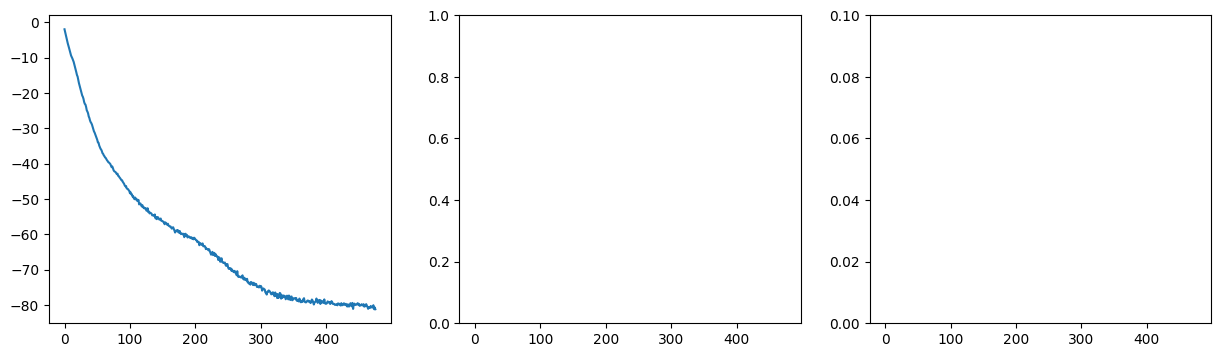

  0%|          | 0/100000 [00:00<?, ?it/s]


In [106]:
for steps in tqdm(range(100_000)):
    
    # break
    
    obs, action, next_obs, timeout, _ = get_iql_training_data(dataset, batch_size=1024)
    # random_obs = next_obs[torch.randperm(next_obs.shape[0])]
    
    loss = sf_loss_function(sf_agent, obs, action, next_obs)
    
    sf_agent.optimizer.zero_grad()
    loss.backward()
    sf_agent.optimizer.step()
    
    soft_update_params(sf_agent.f, sf_agent.target_f, tau=0.01)
    soft_update_params(sf_agent.g, sf_agent.target_g, tau=0.01)
    
    losses.append(loss.item())
    
    
    
    
    if steps % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        axs[0].plot(losses)
        axs[1].plot(losses)
        axs[1].set_ylim([0, 1])
        axs[2].plot(losses)
        axs[2].set_ylim([0, 0.1])
        plt.show()
    
    break

In [39]:
# torch.save(sf_agent.state_dict(), f'shared_models/sf_models/{SF_METHOD}.pth')

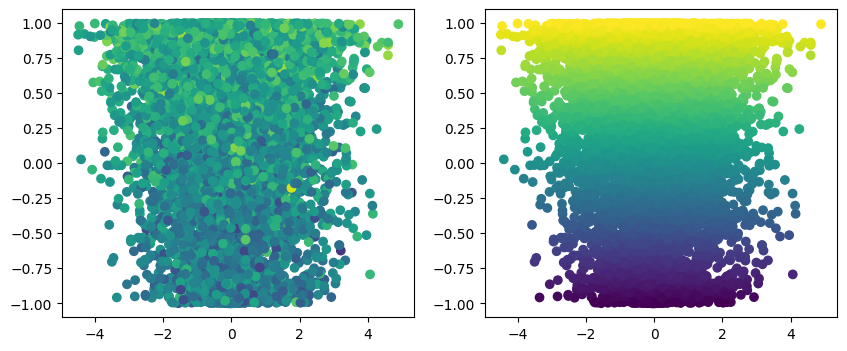

In [95]:
nb_eval_samples = 10000
eval_obs, _, _, _, eval_aux = get_iql_training_data(dataset, batch_size=nb_eval_samples)
benchmark_id = 0
benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
if ENV_NAME == 'antmaze':
    eval_reward = benchmark_reward_function(eval_obs.cpu(), benchmark_param).to(device).float()
else:
    eval_reward = benchmark_reward_function(eval_aux, benchmark_param).to(device).float()


with torch.no_grad():
    # Compute latent variable z:
    z = sf_agent.g(eval_obs).T @ eval_reward
    z = F.normalize(z, dim=-1)


# Predict reward function reconstruction ####################################################################################

nb_eval_samples = 10000
eval_obs, _, _, _, eval_aux = get_iql_training_data(dataset, batch_size=nb_eval_samples)
if ENV_NAME == 'antmaze':
    eval_reward = benchmark_reward_function(eval_obs.cpu(), benchmark_param).cpu().float()
else:
    eval_reward = benchmark_reward_function(eval_aux, benchmark_param).cpu().float()


with torch.no_grad():
    # Compute latent variable z:

    expectation_obs = eval_obs
    exp_B = sf_agent.g(expectation_obs)
    exp_B = F.normalize(exp_B, dim=0)
    C = (exp_B.T @ exp_B)
    inv_C = torch.inverse(C)
    B = sf_agent.g(eval_obs)
    pred_reward = ((B @ inv_C) @ z.unsqueeze(-1)).flatten().cpu()



fig, axs = plt.subplots(1, 2, figsize=(10, 4))
if ENV_NAME == 'antmaze':
    axs[0].scatter(eval_obs[:, 0].cpu(), eval_obs[:, 1].cpu(), c=pred_reward)
    axs[1].scatter(eval_obs[:, 0].cpu(), eval_obs[:, 1].cpu(), c=eval_reward)
    add_largest_maze_walls(axs[0])
    add_largest_maze_walls(axs[1])
elif ENV_NAME == 'plusmaze':
    axs[0].scatter(eval_obs[:, 0].cpu(), eval_obs[:, 1].cpu(), c=pred_reward)
    axs[1].scatter(eval_obs[:, 0].cpu(), eval_obs[:, 1].cpu(), c=eval_reward)
elif ENV_NAME == 'cheetah':
    axs[0].scatter(eval_obs[:, 8].cpu(), eval_aux[:, 0].cpu(), c=pred_reward)
    axs[1].scatter(eval_obs[:, 8].cpu(), eval_aux[:, 0].cpu(), c=eval_reward)
elif ENV_NAME == 'quadruped':
    axs[0].scatter(eval_aux[:, 0].cpu(), eval_aux[:, 3].cpu(), c=pred_reward)
    axs[1].scatter(eval_aux[:, 0].cpu(), eval_aux[:, 3].cpu(), c=eval_reward)

# Training a policy:

In [107]:
class TruncatedNormal(torch.distributions.Normal):
    def __init__(self, loc, scale, low=-1.0, high=1.0, eps=1e-6) -> None:
        super().__init__(loc, scale, validate_args=False)
        self.low = low
        self.high = high
        self.eps = eps

    def _clamp(self, x) -> torch.Tensor:
        clamped_x = torch.clamp(x, self.low + self.eps, self.high - self.eps)
        x = x - x.detach() + clamped_x.detach()
        return x

    def sample(self, clip=None, sample_shape=torch.Size()) -> torch.Tensor:  # type: ignore
        shape = self._extended_shape(sample_shape)
        eps = torch.distributions.utils._standard_normal(shape,
                               dtype=self.loc.dtype,
                               device=self.loc.device)
        eps *= self.scale
        if clip is not None:
            eps = torch.clamp(eps, -clip, clip)
        x = self.loc + eps
        return self._clamp(x)


class Actor(nn.Module):
    def __init__(self, obs_dim, z_dim, action_dim, feature_dim, hidden_dim,
                 preprocess=False, add_trunk=True) -> None:
        super().__init__()
        self.obs_dim = obs_dim
        self.z_dim = z_dim
        self.action_dim = action_dim
        self.preprocess = preprocess

        if self.preprocess:
            self.obs_net = mlp(self.obs_dim, hidden_dim, "ntanh", feature_dim, "irelu")
            self.obs_z_net = mlp(self.obs_dim + self.z_dim, hidden_dim, "ntanh", feature_dim, "irelu")
            if not add_trunk:
                self.trunk: nn.Module = nn.Identity()
                feature_dim = 2 * feature_dim
            else:
                self.trunk = mlp(2 * feature_dim, hidden_dim, "irelu")
                feature_dim = hidden_dim
        else:
            self.trunk = mlp(self.obs_dim + self.z_dim, hidden_dim, "ntanh",
                             hidden_dim, "irelu",
                             hidden_dim, "irelu")
            feature_dim = hidden_dim

        self.policy = mlp(feature_dim, hidden_dim, "irelu", self.action_dim)
        # self.apply(utils.weight_init)
        # initialize the last layer by zero
        # self.policy[-1].weight.data.fill_(0.0)

    def forward(self, obs, z, std):
        assert z.shape[-1] == self.z_dim

        if self.preprocess:
            obs_z = self.obs_z_net(torch.cat([obs, z], dim=-1))
            obs = self.obs_net(obs)
            h = torch.cat([obs, obs_z], dim=-1)
        else:
            h = torch.cat([obs, z], dim=-1)
        if hasattr(self, "trunk"):
            h = self.trunk(h)
        mu = self.policy(h)
        mu = torch.tanh(mu)
        std = torch.ones_like(mu) * std

        dist = TruncatedNormal(mu, std)
        return dist




class ForwardMap(nn.Module):
    """ forward representation class"""

    def __init__(self, obs_dim, z_dim, action_dim, feature_dim, hidden_dim, output_dim,
                 preprocess=False, add_trunk=True) -> None:
        super().__init__()
        self.obs_dim = obs_dim
        self.z_dim = z_dim
        self.action_dim = action_dim
        self.output_dim = output_dim
        self.preprocess = preprocess

        if self.preprocess:
            self.obs_action_net = mlp(self.obs_dim + self.action_dim, hidden_dim, "ntanh", feature_dim, "irelu")
            self.obs_z_net = mlp(self.obs_dim + self.z_dim, hidden_dim, "ntanh", feature_dim, "irelu")
            if not add_trunk:
                self.trunk: nn.Module = nn.Identity()
                feature_dim = 2 * feature_dim
            else:
                self.trunk = mlp(2 * feature_dim, hidden_dim, "irelu")
                feature_dim = hidden_dim
        else:
            self.trunk = mlp(self.obs_dim + self.z_dim + self.action_dim, hidden_dim, "ntanh",
                             hidden_dim, "irelu",
                             hidden_dim, "irelu")
            feature_dim = hidden_dim

        seq = [feature_dim, hidden_dim, "irelu", self.output_dim]
        self.F1 = mlp(*seq)
        self.F2 = mlp(*seq)

        # self.apply(utils.weight_init)

    def forward(self, obs, z, action):
        assert z.shape[-1] == self.z_dim

        if self.preprocess:
            obs_action = self.obs_action_net(torch.cat([obs, action], dim=-1))
            obs_z = self.obs_z_net(torch.cat([obs, z], dim=-1))
            h = torch.cat([obs_action, obs_z], dim=-1)
        else:
            h = torch.cat([obs, z, action], dim=-1)
        if hasattr(self, "trunk"):
            h = self.trunk(h)
        F1 = self.F1(h)
        F2 = self.F2(h)
        return F1, F2




class DDPG(nn.Module):
    def __init__(self, obs_dim, z_dim, action_dim):
        super(DDPG, self).__init__()
        
        hidden_dim = 1024
        
        self.actor = Actor(obs_dim, z_dim, action_dim, feature_dim=512, hidden_dim=1024, preprocess=True)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=1e-4)
        
        
        # self.Q1 = mlp(obs_dim + action_dim + z_dim, hidden_dim, "ntanh", 
        #                 hidden_dim, "irelu",
        #                 hidden_dim, "irelu",
        #                 1,
        #             )
        
        # self.Q2 = mlp(obs_dim + action_dim + z_dim, hidden_dim, "ntanh", 
        #                 hidden_dim, "irelu",
        #                 hidden_dim, "irelu",
        #                 1,
        #             )
        
        self.successor_net = ForwardMap(obs_dim, z_dim, action_dim, feature_dim=512, hidden_dim=1024, output_dim=1, preprocess=True, add_trunk=True)
        
        # self.Q_optimizer = torch.optim.Adam([
        #         {'params': self.Q1.parameters()},  # type: ignore
        #         {'params': self.Q2.parameters()}
        #     ], lr=1e-4)
        self.Q_optimizer = torch.optim.Adam(self.successor_net.parameters(), lr=1e-4)
        
        
        # self.Q1_target = mlp(
        #     obs_dim + action_dim + z_dim, hidden_dim, "ntanh",
        #     hidden_dim, "irelu",
        #     hidden_dim, "irelu",
        #     1,
        # )
        # self.Q2_target = mlp(
        #     obs_dim + action_dim + z_dim, hidden_dim, "ntanh",
        #     hidden_dim, "irelu",
        #     hidden_dim, "irelu",
        #     1,
        # )

        # self.Q1_target.load_state_dict(self.Q1.state_dict())
        # self.Q2_target.load_state_dict(self.Q2.state_dict())
        
        self.target_successor_net = ForwardMap(obs_dim, z_dim, action_dim, feature_dim=512, hidden_dim=1024, output_dim=1, preprocess=True, add_trunk=True)
        self.target_successor_net.load_state_dict(self.successor_net.state_dict())
        
        
        
    def actor_forward(self, obs, z, std=0.2):
        return self.actor(obs, z, std)
    
    
    def target_critic_forward(self, obs, action, z):
        # s_a_z = torch.cat([obs, action, z], dim=-1)
        # return self.Q1(s_a_z), self.Q2(s_a_z)
        return self.target_successor_net(obs, z, action)
        
    def critic_forward(self, obs, action, z):
        # s_a_z = torch.cat([obs, action, z], dim=-1)
        # return self.Q1_target(s_a_z), self.Q2_target(s_a_z)
        return self.successor_net(obs, z, action)

In [119]:
agent = DDPG(obs_dim=STATE_DIM, z_dim=Z_DIM, action_dim=ACTION_DIM).to(device)

In [120]:
actor_losses = []
rewards_list = []

In [122]:
for steps in tqdm(range(1_000_000)):
    
    num_reward_functions = 32
    num_states = 128
    batch_size = num_reward_functions*num_states

    z = torch.normal(0, 1, size=(num_reward_functions, Z_DIM), device=device)
    z = F.normalize(z, dim=-1).unsqueeze(1).repeat(1, num_states, 1).reshape(-1, 50)
    z = torch.zeros_like(z)
    obs, action, next_obs, terminals, obs_aux = get_iql_training_data(dataset, batch_size=batch_size)
    
    
    with torch.no_grad():
        # reward = (sf_agent.g(obs) * z).sum(dim=-1).unsqueeze(-1)
        benchmark_reward_function, _, benchmark_param = benchmarks[0]
        reward = benchmark_reward_function(obs_aux, benchmark_param).to(device).float().unsqueeze(-1)

    # ------------------------------------------------------------------
    # 2) Compute target Q values with next actions
    # ------------------------------------------------------------------
    with torch.no_grad():
        # Sample next action from actor
        dist = agent.actor_forward(next_obs, z)
        next_action = dist.sample(clip=0.3)

        # Q-targets: min over twin critics
        q1_target, q2_target = agent.target_critic_forward(next_obs, next_action, z)
        q_target = torch.min(q1_target, q2_target)

        y = reward + 0.99 * (1 - terminals) * q_target
        
        
    # ------------------------------------------------------------------
    # 3) Critic update
    # ------------------------------------------------------------------
    q1_pred, q2_pred = agent.critic_forward(obs, action, z)
    critic_loss = F.mse_loss(q1_pred, y) + F.mse_loss(q2_pred, y)

    agent.Q_optimizer.zero_grad()
    critic_loss.backward()
    agent.Q_optimizer.step()

    # break

    # soft_update_params(agent.Q1, agent.Q1_target, tau=0.001)
    # soft_update_params(agent.Q2, agent.Q2_target, tau=0.001)
    soft_update_params(agent.successor_net, agent.target_successor_net, tau=0.001)

    # ------------------------------------------------------------------
    # 4) Actor update
    # ------------------------------------------------------------------

    z = torch.normal(0, 1, size=(batch_size, Z_DIM), device=device)
    z = F.normalize(z, dim=-1)
    z = torch.zeros_like(z)
    obs, _, _, _, _ = get_iql_training_data(dataset, batch_size=batch_size)

    dist = agent.actor_forward(obs, z)
    action = dist.sample(clip=0.3)
    
    q1_pred, q2_pred = agent.critic_forward(obs, action, z)
    Q = torch.min(q1_pred, q2_pred) 
    
    

    actor_loss = -Q.mean()

    agent.actor_optimizer.zero_grad()
    actor_loss.backward()
    agent.actor_optimizer.step()
    
    
    actor_losses.append(actor_loss.item())
    
    # break
    # continue
    
    if steps % 1000 == 0:
        clear_output(True)
        run_benchmark_rewards = run_benchmark(env, agent, benchmarks, 1)
        plt.show()
        
        rewards_list.append(run_benchmark_rewards[2])
        
        plt.plot(rewards_list)
        plt.show()
    
    break

  0%|          | 46/1000000 [00:03<21:44:22, 12.78it/s]


KeyboardInterrupt: 

goal_mid_bottom


UnboundLocalError: local variable 'z' referenced before assignment

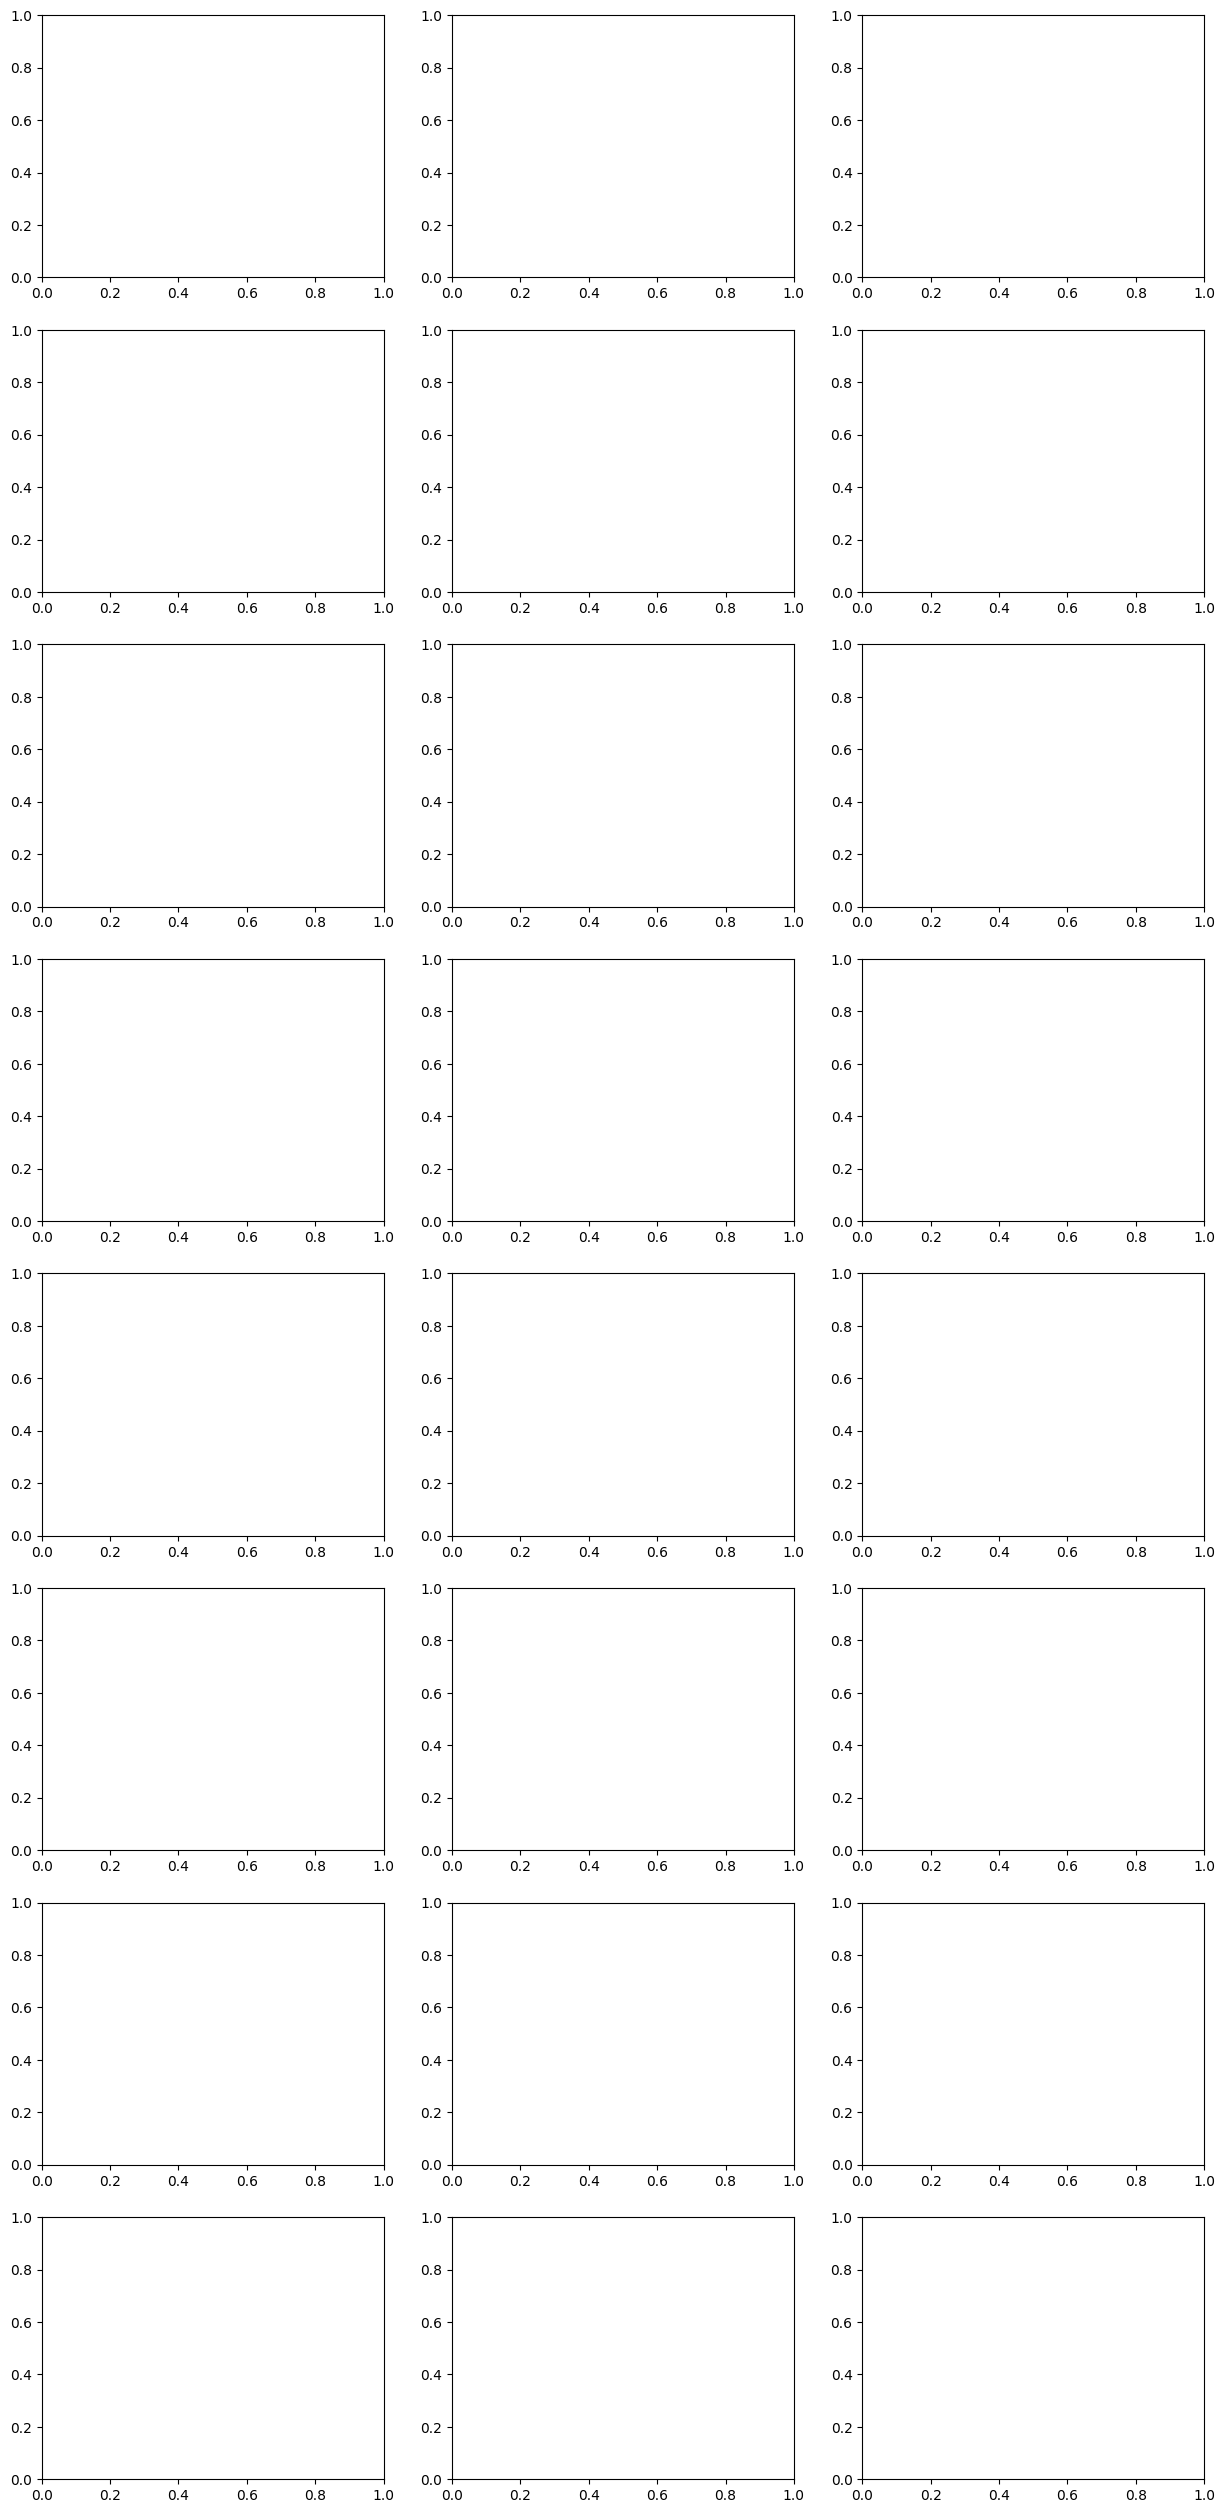

In [126]:
run_benchmark_rewards = run_benchmark(env, agent, benchmarks, 1)

In [264]:
str(list(run_benchmark_rewards.round(4)))

[0.0284, 0.22, 1.0685, 0.2359, 0.321]